In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
from sklearn.preprocessing import MultiLabelBinarizer

In [123]:
df = pd.read_csv('data/movies.csv')

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


### Plan
firstly, date -> split into years and months

then, perform eda on these features to confirm selection:
- year, month, genre, orig-lang, budget, revenue, country -> 7 total

additional features to test if the we have enough time:
- crew, overview(tf-idf) -> 2 total

score(rating) is our target value

In [125]:
df.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [126]:
df.head(3)

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU


### Plans for Models to use

1. Linear Regression
2. Random Forest
3. XgBoost -> Gradient Boosting

In [127]:
# convert the str date column into datetime
df['date_x'] = pd.to_datetime(df['date_x'])

# extract new year and month columns from date
df['year'] = df['date_x'].dt.year
df['month'] = df['date_x'].dt.month

In [128]:
df['year'].isna().sum()

np.int64(0)

In [129]:
genres = df["genre"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)

mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(
    mlb.fit_transform(genres),
    columns=mlb.classes_,
    index=df.index
)

display(genre_features.head())

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
3,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


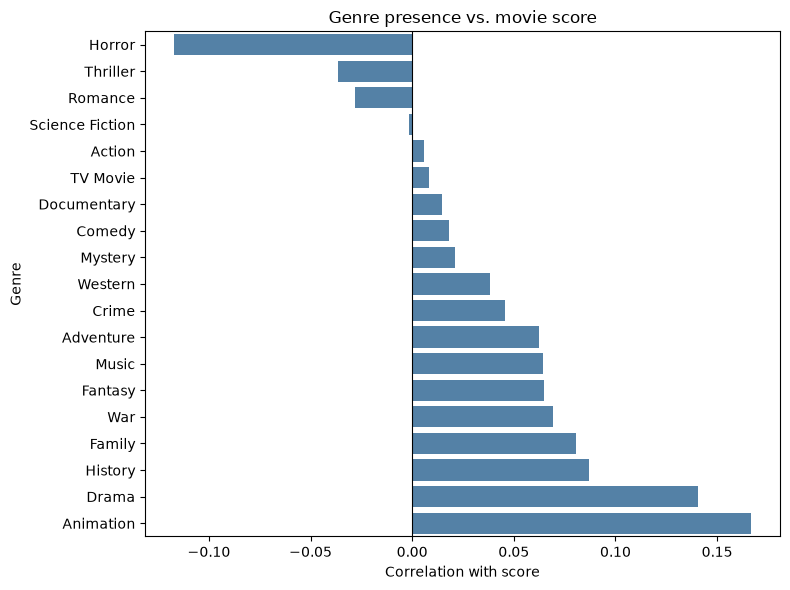

In [130]:
correlations = (
    genre_features.corrwith(df["score"])
    .dropna()
    .sort_values()
)

plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with score")
plt.ylabel("Genre")
plt.title("Genre presence vs. movie score")
plt.tight_layout()
plt.show()

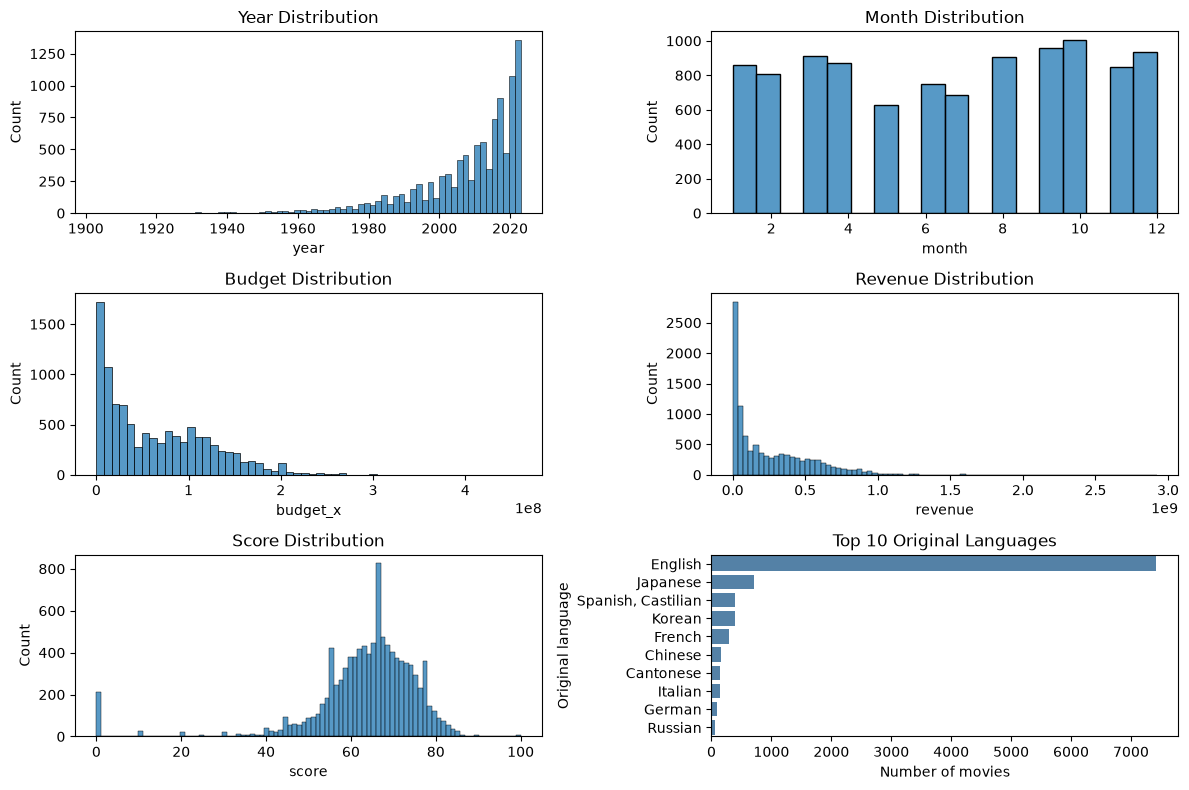

In [131]:
# Create a 1x2 grid (1 row, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# First plot on the left axis - Year
sns.histplot(df, x=df['year'], ax=axes[0][0])
axes[0][0].set_title("Year Distribution")

# Second plot on the right axis - Month
sns.histplot(df, x=df['month'], ax=axes[0][1])
axes[0][1].set_title("Month Distribution")

# budget 
sns.histplot(df, x=df['budget_x'], ax=axes[1][0])
axes[1][0].set_title("Budget Distribution")

# revenue
sns.histplot(df, x=df['revenue'], ax=axes[1][1])
axes[1][1].set_title("Revenue Distribution")

# Score
sns.histplot(df, x=df['score'], ax=axes[2][0])
axes[2][0].set_title("Score Distribution")

# original language: top 10 languages
top_languages = df['orig_lang'].str.strip().value_counts().head(10)
sns.barplot(
    x=top_languages.values,
    y=top_languages.index,
    ax=axes[2][1],
    color="steelblue"
)
axes[2][1].set_title("Top 10 Original Languages")
axes[2][1].set_xlabel("Number of movies")
axes[2][1].set_ylabel("Original language")

# Adjust spacing and display
plt.tight_layout()
plt.show()

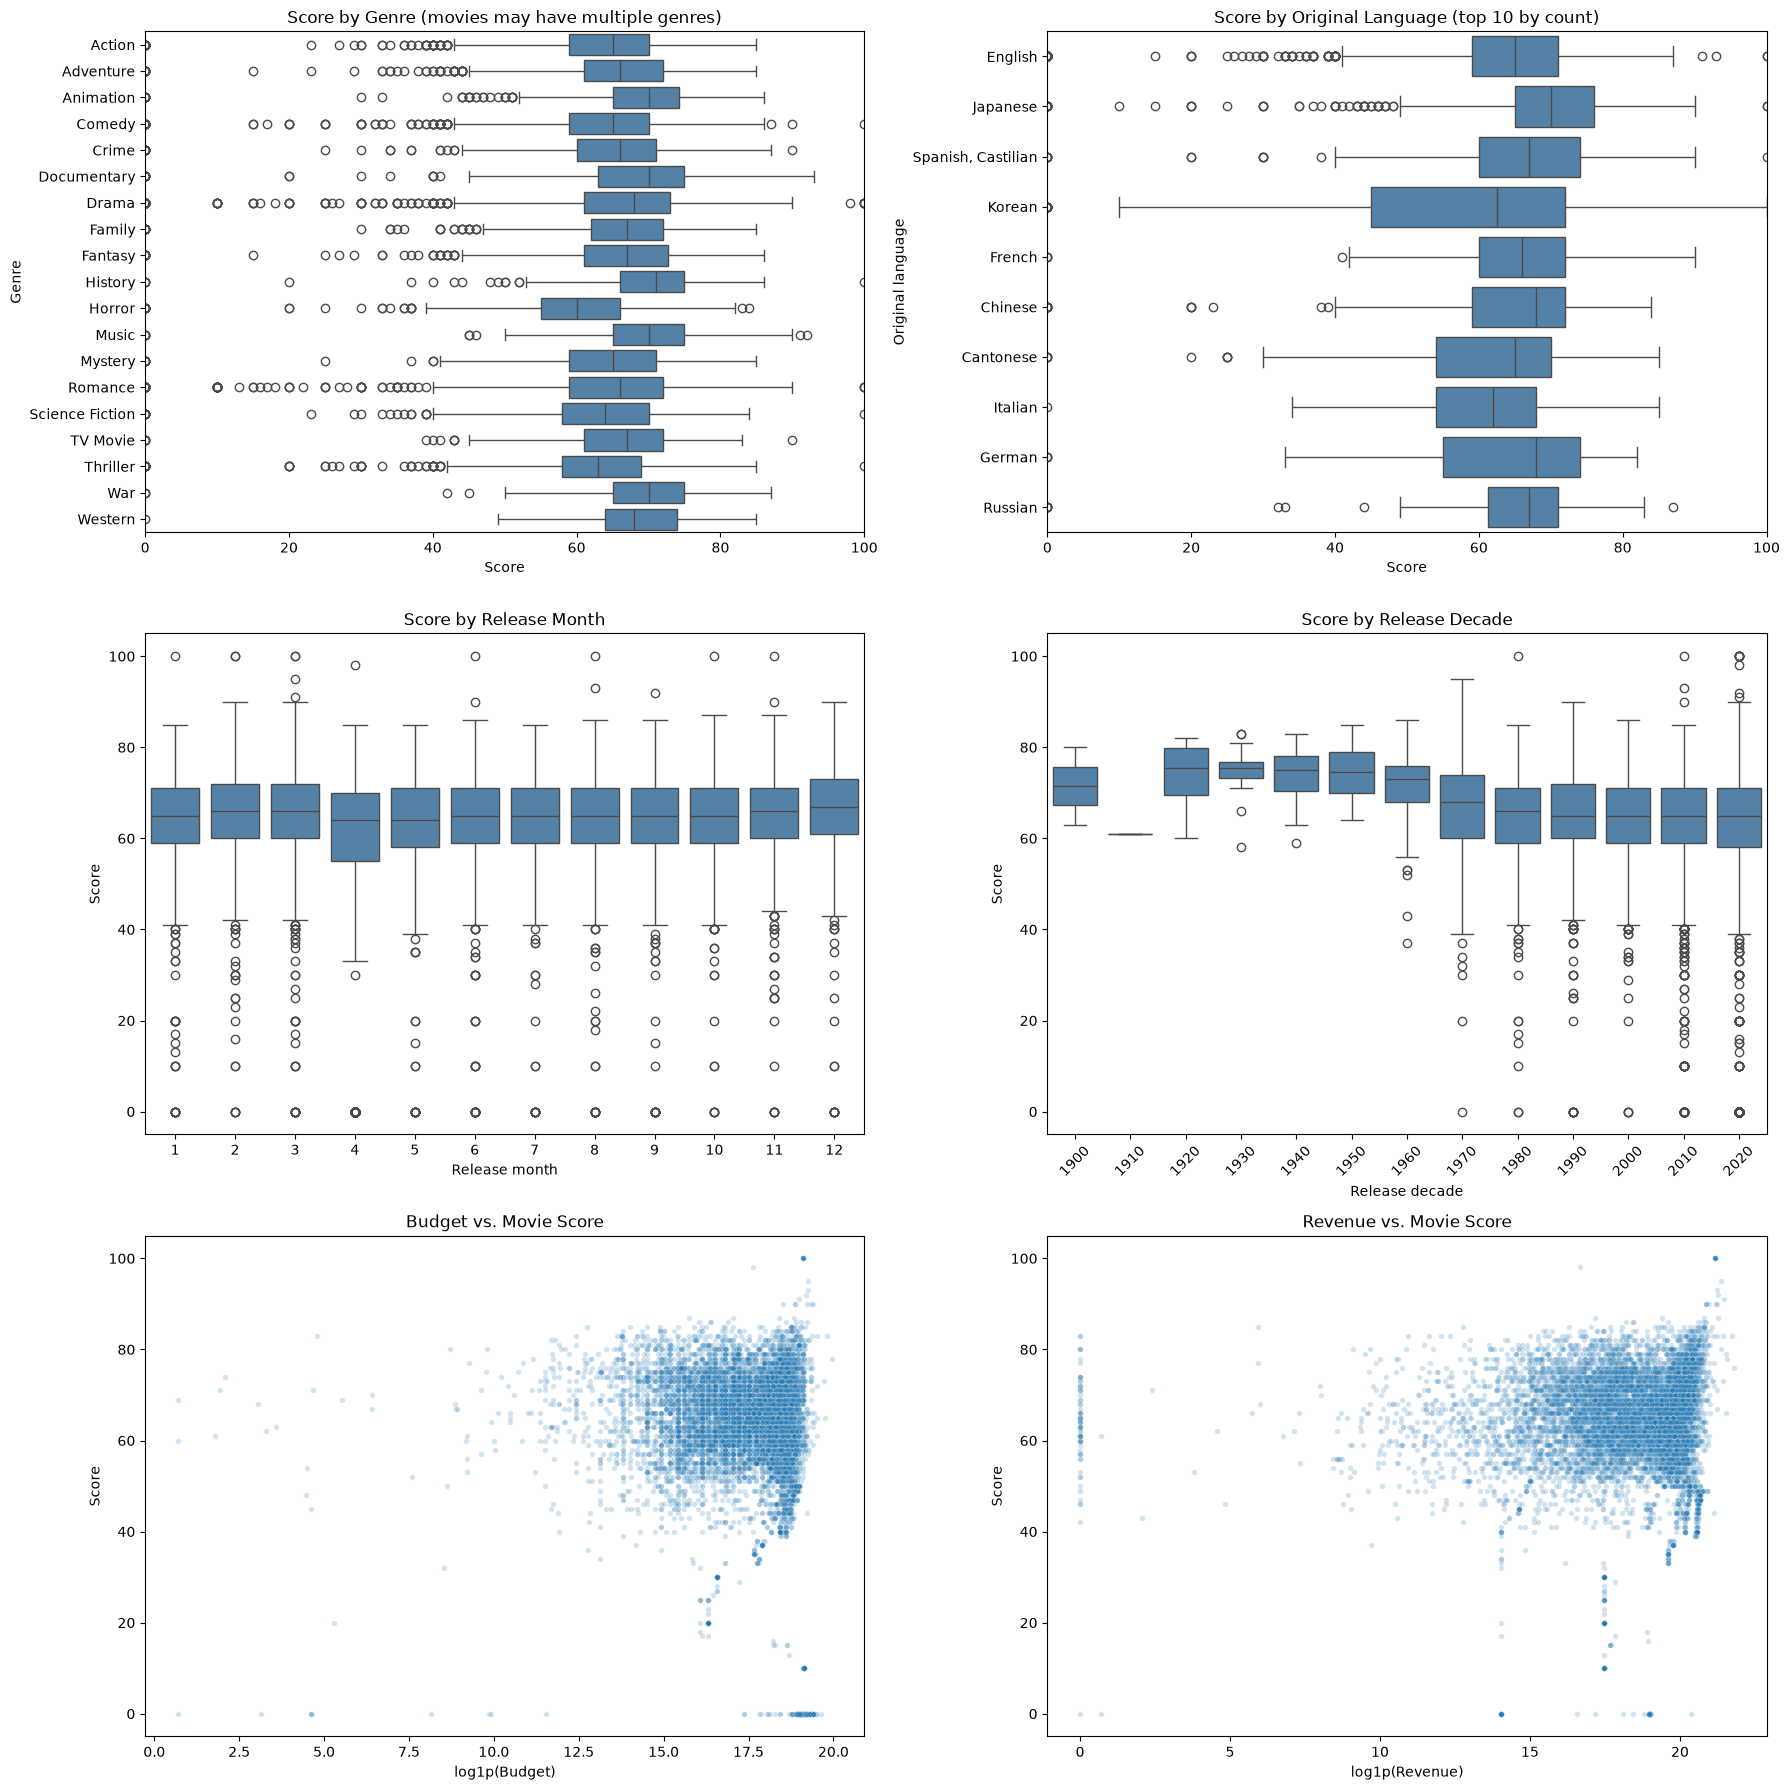

In [132]:
# Compare movie scores with each feature using the current df
plot_df = df.copy()
plot_df["language"] = plot_df["orig_lang"].str.strip()
plot_df["decade"] = (plot_df["year"] // 10) * 10

# A movie appears once per genre it belongs to; skip missing genres
plot_df["genre_list"] = plot_df["genre"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)
genre_scores = plot_df[["score", "genre_list"]].explode("genre_list")
genre_scores = genre_scores.dropna(subset=["genre_list"])
genre_order = sorted(genre_scores["genre_list"].unique())
language_order = plot_df["language"].value_counts().head(10).index.tolist()
decade_order = sorted(plot_df["decade"].dropna().unique())

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sns.boxplot(data=genre_scores, x="score", y="genre_list",
            order=genre_order, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Score by Genre (movies may have multiple genres)")
axes[0, 0].set_ylabel("Genre")

sns.boxplot(data=plot_df, x="score", y="language",
            order=language_order, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Score by Original Language (top 10 by count)")
axes[0, 1].set_ylabel("Original language")

sns.boxplot(data=plot_df, x="month", y="score",
            order=list(range(1, 13)), ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Score by Release Month")
axes[1, 0].set_xlabel("Release month")

sns.boxplot(data=plot_df, x="decade", y="score",
            order=decade_order, ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Score by Release Decade")
axes[1, 1].set_xlabel("Release decade")
axes[1, 1].tick_params(axis="x", rotation=45)

for ax, column, label in [
    (axes[2, 0], "budget_x", "Budget"),
    (axes[2, 1], "revenue", "Revenue")
]:
    # log1p retains zero values; negative/missing money is excluded
    valid = plot_df[column].notna() & plot_df[column].ge(0)
    sns.scatterplot(x=np.log1p(plot_df.loc[valid, column]),
                    y=plot_df.loc[valid, "score"],
                    alpha=0.2, s=15, ax=ax)
    ax.set_xlabel(f"log1p({label})")
    ax.set_title(f"{label} vs. Movie Score")

for ax in axes.flat:
    ax.set_xlim(0, 100) if ax in (axes[0, 0], axes[0, 1]) else None
    ax.set_xlabel("Score") if ax in (axes[0, 0], axes[0, 1]) else None
    ax.set_ylabel("Score") if ax not in (axes[0, 0], axes[0, 1]) else None

plt.tight_layout()
plt.show()


In [133]:
# Counts help distinguish well-supported patterns from small groups
print("Genre summaries (a movie can contribute to several genres)")
display(genre_scores.groupby("genre_list")["score"]
        .agg(["count", "mean", "median", "std"]).round(2))

print("Original language summaries (top 10 by count)")
display(plot_df.groupby("language")["score"]
        .agg(["count", "mean", "median", "std"])
        .reindex(language_order).round(2))

print("Release month summaries")
display(plot_df.groupby("month")["score"]
        .agg(["count", "mean", "median", "std"])
        .reindex(range(1, 13)).round(2))

print("Release decade summaries")
display(plot_df.groupby("decade")["score"]
        .agg(["count", "mean", "median", "std"]).round(2))


Genre summaries (a movie can contribute to several genres)


,count,mean,median,std
genre_list,,,,
Action,2752,63.63,65.0,11.22
Adventure,1890,65.27,66.0,10.59
Animation,1468,68.99,70.0,9.39
Comedy,2943,63.88,65.0,11.25
Crime,1272,65.12,66.0,10.60
Documentary,217,64.85,70.0,19.67
Drama,3812,65.95,68.0,12.91
Family,1407,66.21,67.0,9.49
Fantasy,1382,65.72,67.0,11.16


Original language summaries (top 10 by count)


,count,mean,median,std
language,,,,
English,7417,64.01,65.0,11.14
Japanese,714,66.90,70.0,15.55
"Spanish, Castilian",397,65.19,67.0,13.55
Korean,388,54.89,62.5,24.49
French,285,64.86,66.0,10.96
Chinese,153,61.62,68.0,18.58
Cantonese,145,60.07,65.0,15.95
Italian,142,61.16,62.0,12.03
German,93,62.57,68.0,16.55


Release month summaries


,count,mean,median,std
month,,,,
1,861,63.61,65.0,12.44
2,805,64.81,66.0,11.43
3,912,64.22,66.0,12.66
4,874,56.63,64.0,23.19
5,630,62.71,64.0,13.31
6,749,62.96,65.0,14.47
7,688,63.65,65.0,12.30
8,908,63.66,65.0,11.91
9,957,63.88,65.0,11.75


Release decade summaries


,count,mean,median,std
decade,,,,
1900,2,71.50,71.5,12.02
1910,2,61.00,61.0,0.00
1920,10,74.30,75.5,7.04
1930,22,74.77,75.5,5.37
1940,35,74.17,75.0,6.12
1950,78,74.55,74.5,5.53
1960,141,71.22,73.0,7.56
1970,284,65.58,68.0,11.86
1980,629,64.18,66.0,10.94


In [134]:
df['budget_x'].corr(df["score"])

np.float64(-0.23547009911115668)

In [135]:
df['revenue'].corr(df['score'])

np.float64(0.09653287052495267)

In [136]:
df['status'].unique()

<StringArray>
[' Released', ' Post Production', ' In Production']
Length: 3, dtype: str

In [137]:
df['status'].count()

np.int64(10178)

In [138]:
df[df['status'] == ' Released']['status'].count()

np.int64(10131)

In [139]:
df[df['status'] != ' Released'].head(3)

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,year,month
117,Fast X,2023-05-19,0.0,"Action, Crime, Thriller",Over many missions and against impossible odds...,"Vin Diesel, Dominic Toretto, Michelle Rodrigue...",Fast X,Post Production,English,340000000.0,0.0,US,2023,5
216,The Little Mermaid,2023-05-26,0.0,"Adventure, Family, Fantasy, Romance","The youngest of King Triton’s daughters, and t...","Halle Bailey, Ariel, Jonah Hauer-King, Prince ...",The Little Mermaid,Post Production,English,205000000.0,178359863.0,US,2023,5
229,Transformers: Rise of the Beasts,2023-06-09,0.0,"Action, Adventure, Science Fiction",A ‘90s globetrotting adventure that introduces...,"Anthony Ramos, Noah, Dominique Fishback, Elena...",Transformers: Rise of the Beasts,Post Production,English,200000000.0,1240261.6,US,2023,6


In [140]:
df[df['status'] != ' Released']['status'].count()

np.int64(47)

In [141]:
df.drop(df[df['status'] != ' Released'].index, inplace=True)

In [142]:
df[df['status'] != ' Released']['status'].count()

np.int64(0)

In [143]:
df.describe()

,date_x,score,budget_x,revenue,year,month
count,10131,10131.000000,1.013100e+04,1.013100e+04,10131.000000,10131.000000
mean,2008-05-20 20:53:56.482084,63.791630,6.420460e+07,2.537037e+08,2007.875827,6.656204
min,1903-05-15 00:00:00,0.000000,1.000000e+00,0.000000e+00,1903.000000,1.000000
25%,2001-12-06 00:00:00,59.000000,1.459342e+07,2.858954e+07,2001.000000,3.000000
50%,2013-04-04 00:00:00,65.000000,5.000000e+07,1.525003e+08,2013.000000,7.000000
75%,2019-09-20 00:00:00,71.000000,1.044000e+08,4.200408e+08,2019.000000,10.000000
max,2023-12-31 00:00:00,100.000000,4.600000e+08,2.923706e+09,2023.000000,12.000000
std,NaN,12.857197,5.614975e+07,2.782608e+08,15.318120,3.530960


In [144]:
df[df['score'] == 0]['score'].count()

np.int64(164)

In [145]:
df.drop(df[df['score'] == 0].index, inplace=True)

In [146]:
# Create comparison keys without changing the original columns
movie_keys = pd.DataFrame({
    "title": df["orig_title"].str.strip().str.casefold(),
    "date": df["date_x"],
    "language": df["orig_lang"].str.strip().str.casefold(),
    "country": df['country'].str.strip().str.casefold()
})

duplicate_mask = movie_keys.duplicated(keep=False)
extra_duplicates = movie_keys.duplicated(keep="first")

print("Rows in duplicate groups:", duplicate_mask.sum())
print("Extra rows to remove:", extra_duplicates.sum())

# Keep the first occurrence of each matching movie
df = df.loc[~extra_duplicates].copy()

Rows in duplicate groups: 343
Extra rows to remove: 177


In [147]:
# Remove missing genre
# Find missing, empty, or whitespace-only genres
missing_genre = df["genre"].isna() | df["genre"].str.strip().eq("")

print(f"Movies with missing genre: {missing_genre.sum()}")

df.drop(df.index[missing_genre], inplace=True)

Movies with missing genre: 44


## Cleanup process

1. Movies whose status != Released should be removed
2. Movies with 0 rating are removed 
3. Movies deemed duplicate i.e. having same title, date, language and country are removed
4. Movies with missing genre are removed